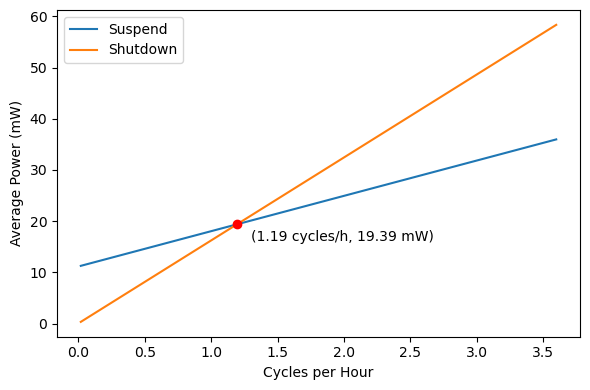

Intersection at Cycles/Hour=1.194517, Avg Power=19.389845 mW


In [14]:
import numpy as np
import matplotlib.pyplot as plt

voltage = 3.3

def suspend(duration):
    activate_power = 110.83
    activate_time = 70
    suspend_power = 3.38
    suspend_time = duration - activate_time
    return (activate_power * activate_time + suspend_power * suspend_time) * voltage / duration

def shutdown(duration):
    activate_power = 155
    activate_time = 114
    shutdown_power = 0.01312
    shutdown_time = duration - activate_time
    return (activate_power * activate_time + shutdown_power * shutdown_time) * voltage / duration

durates = np.arange(1000, 200000, 1)
x = 3600 / durates
y1 = suspend(durates)
y2 = shutdown(durates)

# ---- Find intersection ----
diff = y1 - y2
idx = np.where(np.diff(np.sign(diff)))[0]

if len(idx) == 0:
    raise ValueError('No intersection found in the given range.')

i = idx[0]
d0, d1 = durates[i], durates[i+1]
f0, f1 = diff[i], diff[i+1]

# Linear interpolation for more precise crossing
d_cross = d0 - f0 * (d1 - d0) / (f1 - f0)
x_cross = 3600 / d_cross
y_cross = suspend(d_cross)

# ---- Plot ----
plt.figure(figsize=(6, 4))
plt.plot(x, y1, label='Suspend')
plt.plot(x, y2, label='Shutdown')
plt.scatter([x_cross], [y_cross], color='red', zorder=5)
plt.annotate(f'({x_cross:.2f} cycles/h, {y_cross:.2f} mW)',
             (x_cross, y_cross),
             textcoords='offset points',
             xytext=(10, -12))

plt.legend()
plt.xlabel('Cycles per Hour')
plt.ylabel('Average Power (mW)')
plt.tight_layout()
plt.show()

print(f'Intersection at Cycles/Hour={x_cross:.6f}, Avg Power={y_cross:.6f} mW')
